# Seasonal Agriculture Performance Analysis

### Major Project – Data Analytics

**Student:** Aarush Singh  
**AICTE Student ID:** STU6736c7458b0c11731643205  
**Project:** Seasonal Agriculture Performance Analysis

# Problem Statement

Agricultural performance is influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed under different seasonal conditions.

Therefore, this project analyzes the given agricultural dataset to identify meaningful seasonal patterns, trends, relationships and variations in agricultural productivity, profitability, resource usage and risk.

# Objectives

1. Analyze the structure and characteristics of the agricultural dataset.
2. Clean and prepare the data for analysis.
3. Examine agricultural performance across different seasons.
4. Analyze crop yield, production, revenue, cost and profit.
5. Study the relationship between environmental factors and agricultural performance.
6. Analyze the effect of irrigation and agricultural inputs on yield.
7. Compare resource utilization and water efficiency across seasons.
8. Identify important patterns, trends, relationships and outliers.
9. Develop at least three meaningful student-designed analyses.
10. Generate evidence-based insights and recommendations for improving agricultural performance.

# Project Scope

The analysis focuses on:

- Crop and seasonal performance
- Yield and production
- Rainfall, temperature and humidity
- Soil conditions
- Fertilizer and pesticide usage
- Irrigation methods
- Revenue, cost and profit
- Water consumption and efficiency
- Disease and pest risk
- State and crop-level comparisons

# Analytical Approach

The project follows these stages:

**Data Collection → Data Inspection → Data Cleaning → Exploratory Data Analysis → Statistical Analysis → Seasonal Comparison → Correlation Analysis → Student-Designed Analysis → Insights → Recommendations → Conclusion**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Data Loading

In [2]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 1.1 Top 5 Records

The first five records are examined to understand the structure and type of information available in the dataset.

In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 1.2 Last 5 Records

In [4]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


# 2. Dataset Shape

In [5]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 4000
Columns: 28


# 3. Dataset Structure

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


# 4. Missing Value Analysis

Missing values are checked before performing statistical and visual analysis.

In [8]:
df.isna().sum().sort_values(ascending=False)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


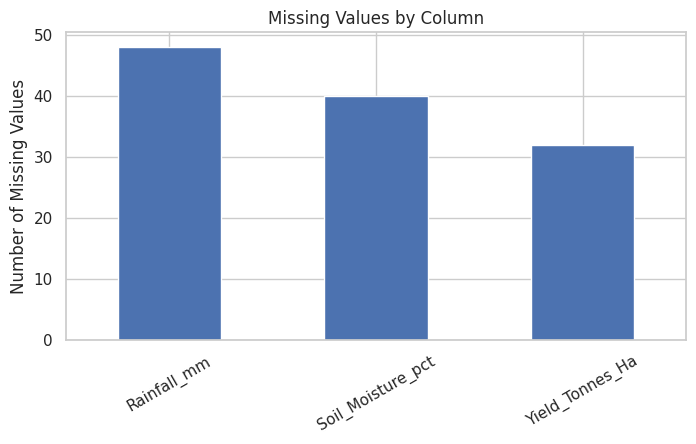

In [9]:
m=df.isna().sum().sort_values(ascending=False)
m=m[m>0]

plt.figure(figsize=(8,4))
m.plot(kind='bar')
plt.title('Missing Values by Column')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=30)
plt.show()

## 4.1 Handling Missing Values

Missing numerical values are replaced using the median of their respective columns. Median imputation is used because it is less affected by extreme values.

In [10]:
for c in ['Rainfall_mm','Soil_Moisture_pct','Yield_Tonnes_Ha']:
    df[c]=df[c].fillna(df[c].median())

print("Remaining missing values:",df.isna().sum().sum())

Remaining missing values: 0


# 5. Duplicate Records

In [11]:
print("Duplicate records:",df.duplicated().sum())

Duplicate records: 0


### Observation

No duplicate records were found in the dataset.

# 6. Descriptive Statistical Analysis

Descriptive statistics are used to understand the central tendency, variability and range of numerical agricultural variables.

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [14]:
df.select_dtypes('number').median().round(2)

,0
Farm_Area_Hectares,7.90
Rainfall_mm,582.00
Avg_Temperature_C,26.90
Humidity_pct,63.00
Sunlight_Hours_Day,7.30
Soil_pH,6.69
Soil_Moisture_pct,26.40
Nitrogen_kg_ha,120.10
Phosphorus_kg_ha,57.50
Potassium_kg_ha,105.10


# 7. Categorical Variable Analysis

In [15]:
for c in ['State','District','Crop','Season','Irrigation_Method']:
    print('\n',c)
    print(df[c].value_counts())


 State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

 District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

 Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

 Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

 Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


# 8. Univariate Analysis

## 8.1 Crop Distribution

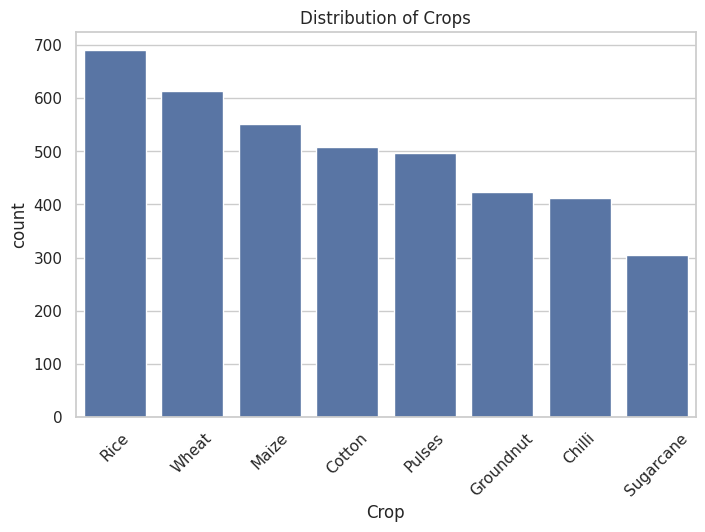

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='Crop',order=df['Crop'].value_counts().index)
plt.title('Distribution of Crops')
plt.xticks(rotation=45)
plt.show()

## 8.2 Season Distribution

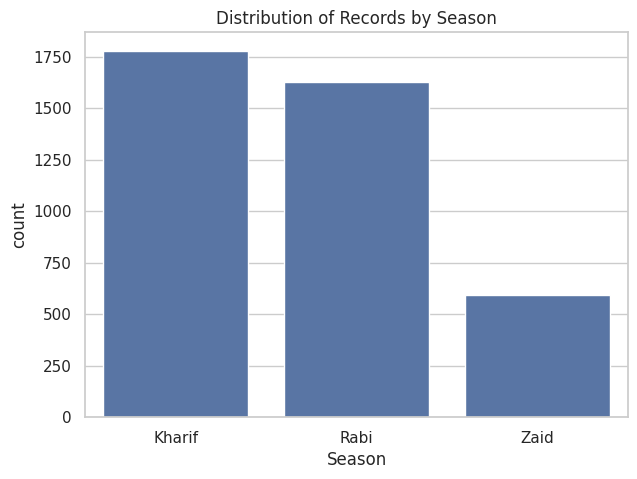

In [17]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x='Season')
plt.title('Distribution of Records by Season')
plt.show()

## 8.3 Irrigation Method Distribution

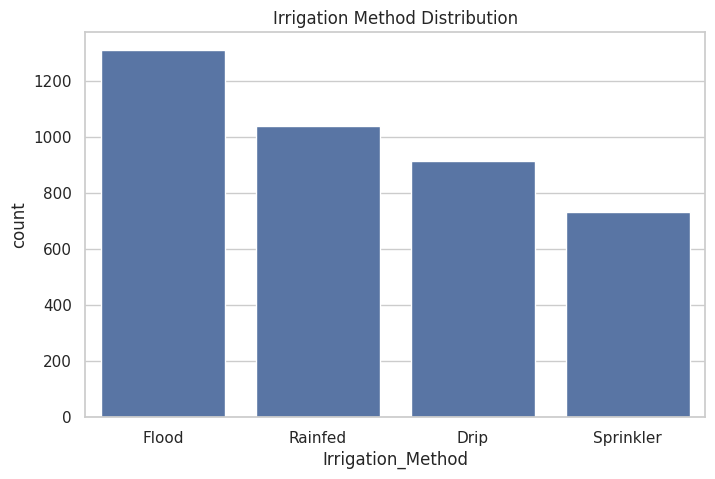

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='Irrigation_Method',order=df['Irrigation_Method'].value_counts().index)
plt.title('Irrigation Method Distribution')
plt.show()

## 8.4 Seasonal Distribution

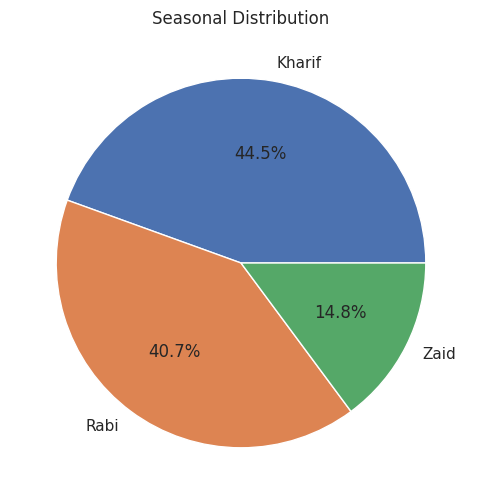

In [19]:
df['Season'].value_counts().plot(kind='pie',autopct='%1.1f%%',figsize=(6,6))
plt.title('Seasonal Distribution')
plt.ylabel('')
plt.show()

## 8.5 Yield Distribution

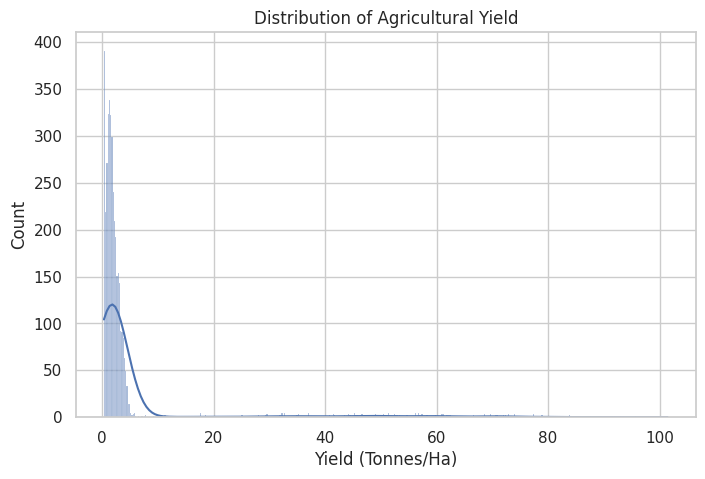

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['Yield_Tonnes_Ha'],kde=True)
plt.title('Distribution of Agricultural Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.show()

## 8.6 Profit Distribution

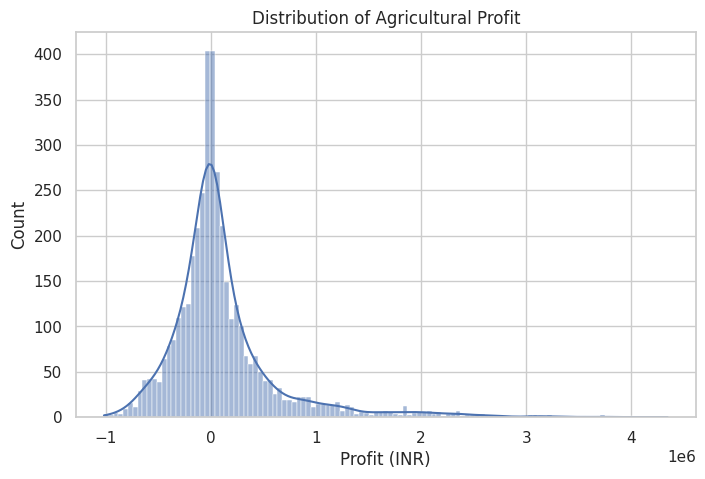

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Profit_INR'],kde=True)
plt.title('Distribution of Agricultural Profit')
plt.xlabel('Profit (INR)')
plt.show()

# 9. Outlier Analysis

Box plots are used to identify unusually high or low observations in important agricultural variables.

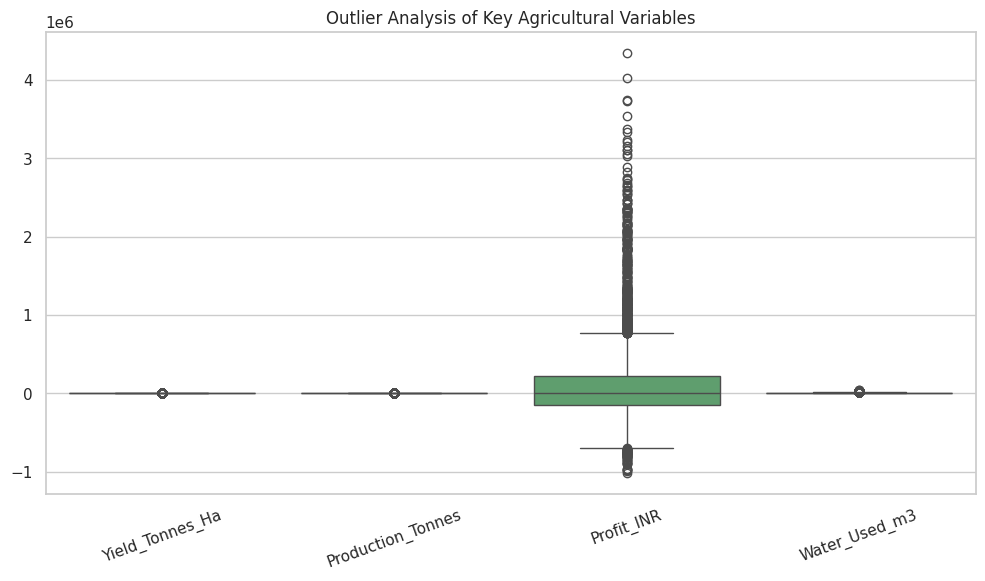

In [22]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Yield_Tonnes_Ha','Production_Tonnes','Profit_INR','Water_Used_m3']])
plt.xticks(rotation=20)
plt.title('Outlier Analysis of Key Agricultural Variables')
plt.show()

In [24]:
for c in ['Yield_Tonnes_Ha','Production_Tonnes','Profit_INR','Water_Used_m3']:
    q1,q3=df[c].quantile([.25,.75])
    iqr=q3-q1
    print(c,((df[c]<q1-1.5*iqr)|(df[c]>q3+1.5*iqr)).sum())

Yield_Tonnes_Ha 302
Production_Tonnes 333
Profit_INR 404
Water_Used_m3 276


# 10. Bivariate Analysis

## 10.1 Season vs Average Yield

This analysis compares agricultural yield across different seasons.

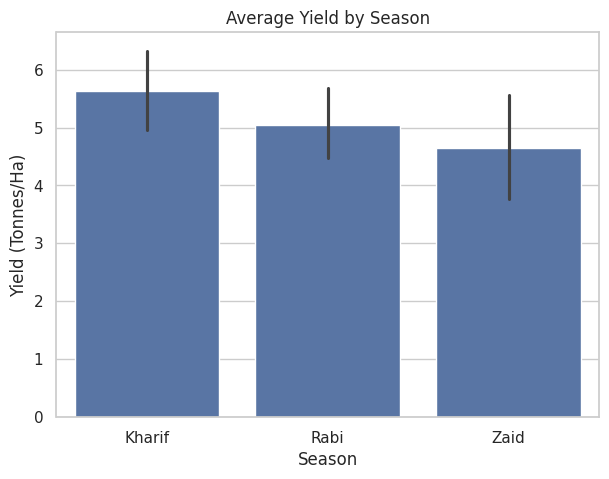

In [25]:
plt.figure(figsize=(7,5))
sns.barplot(data=df,x='Season',y='Yield_Tonnes_Ha')
plt.title('Average Yield by Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

## 10.2 Season vs Average Profit

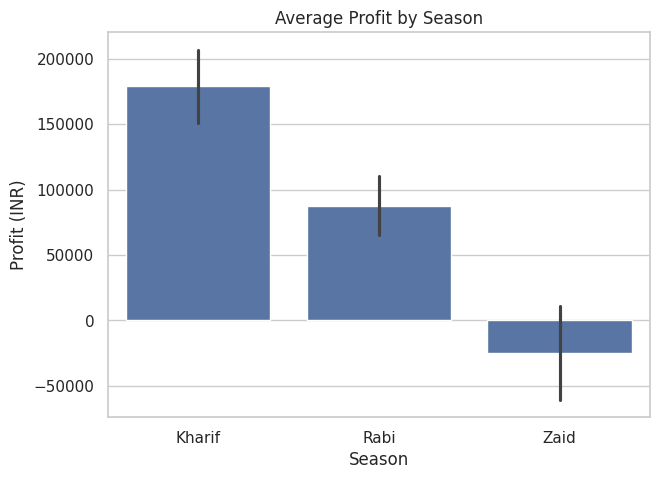

In [26]:
plt.figure(figsize=(7,5))
sns.barplot(data=df,x='Season',y='Profit_INR')
plt.title('Average Profit by Season')
plt.ylabel('Profit (INR)')
plt.show()

## 10.3 Season vs Production

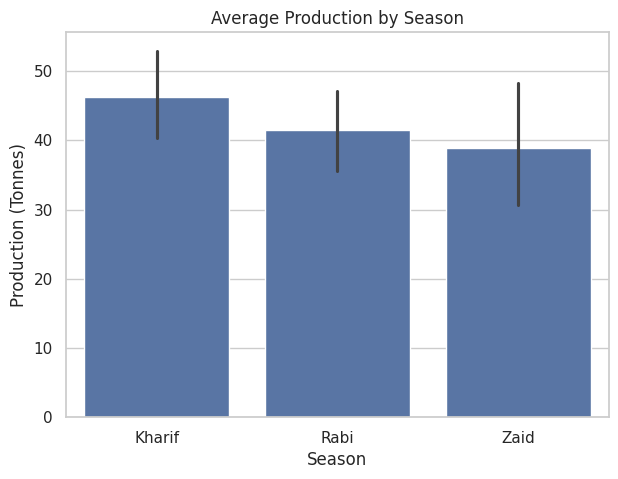

In [27]:
plt.figure(figsize=(7,5))
sns.barplot(data=df,x='Season',y='Production_Tonnes')
plt.title('Average Production by Season')
plt.ylabel('Production (Tonnes)')
plt.show()

## 10.4 Rainfall vs Yield

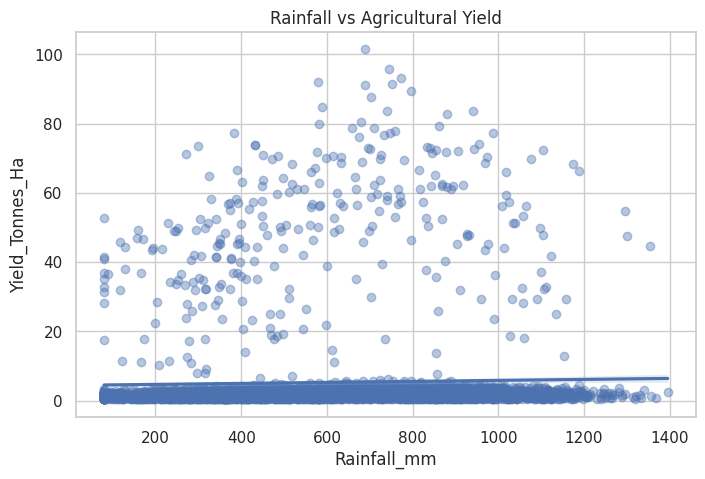

In [28]:
plt.figure(figsize=(8,5))
sns.regplot(data=df,x='Rainfall_mm',y='Yield_Tonnes_Ha',scatter_kws={'alpha':.4})
plt.title('Rainfall vs Agricultural Yield')
plt.show()

## 10.5 Water Usage vs Yield

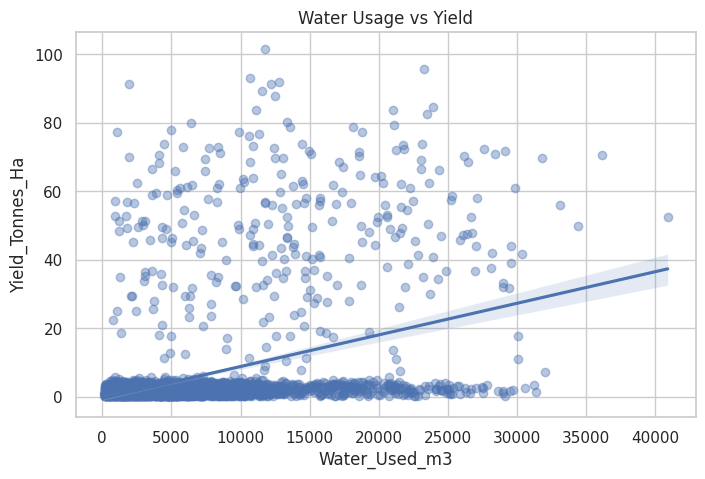

In [29]:
plt.figure(figsize=(8,5))
sns.regplot(data=df,x='Water_Used_m3',y='Yield_Tonnes_Ha',scatter_kws={'alpha':.4})
plt.title('Water Usage vs Yield')
plt.show()

## 10.6 Fertilizer vs Yield

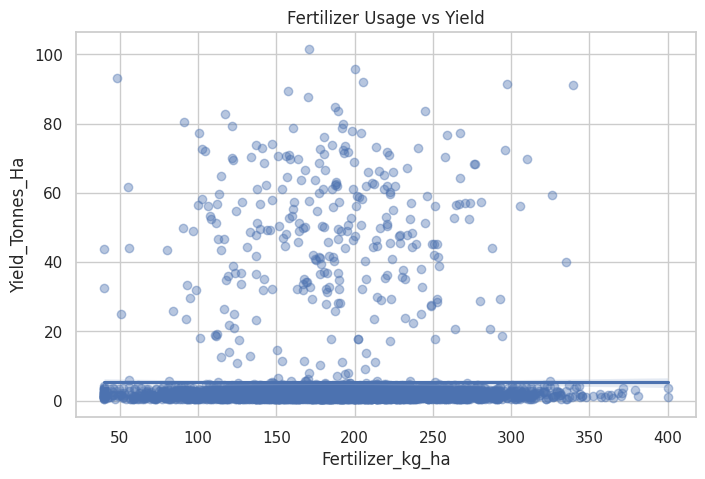

In [30]:
plt.figure(figsize=(8,5))
sns.regplot(data=df,x='Fertilizer_kg_ha',y='Yield_Tonnes_Ha',scatter_kws={'alpha':.4})
plt.title('Fertilizer Usage vs Yield')
plt.show()

## 10.7 Irrigation Method vs Yield

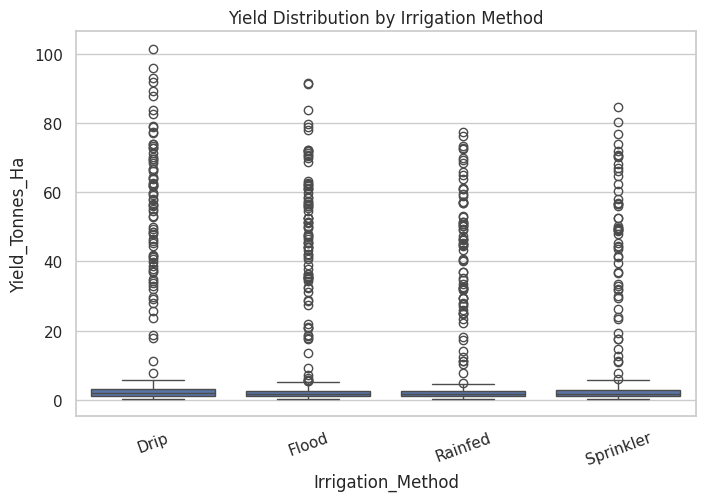

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='Irrigation_Method',y='Yield_Tonnes_Ha')
plt.title('Yield Distribution by Irrigation Method')
plt.xticks(rotation=20)
plt.show()

# 11. Multivariate Analysis

A pairplot is used to examine relationships among environmental conditions, agricultural inputs, yield and profitability.

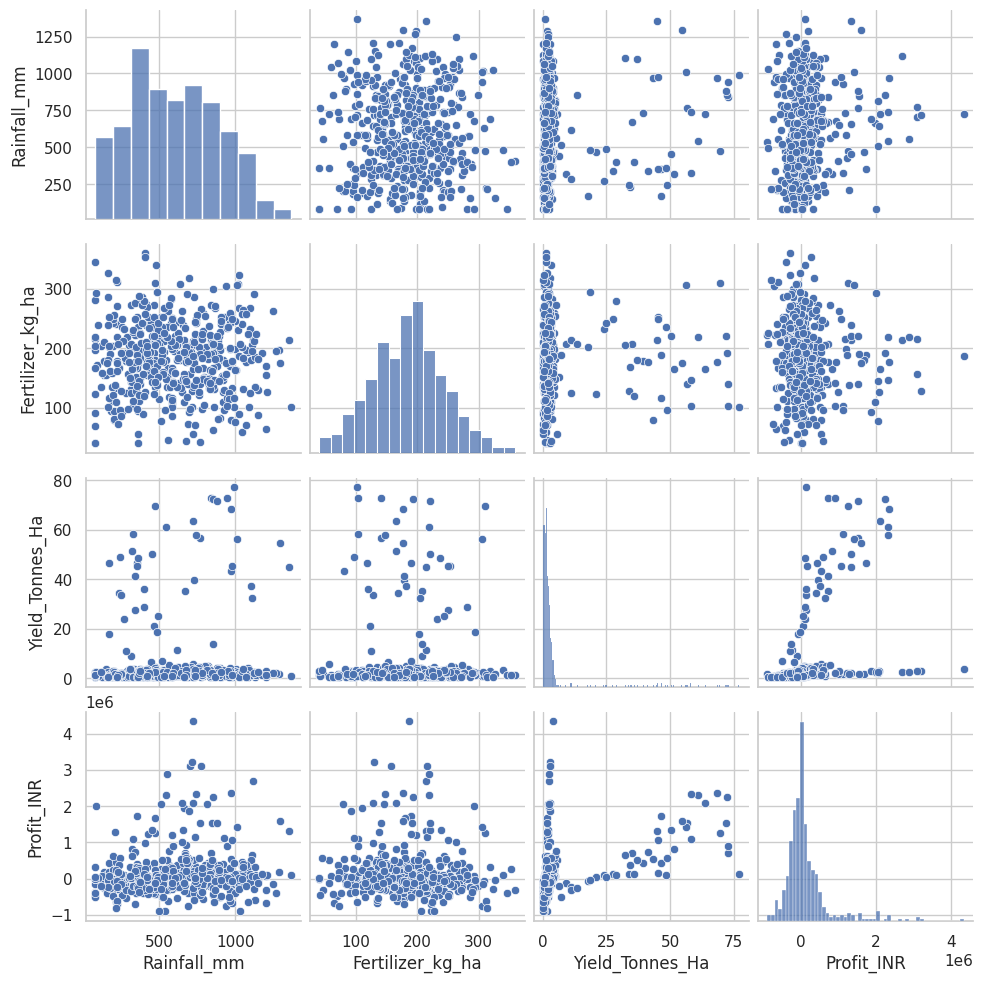

In [32]:
sns.pairplot(
    df[['Rainfall_mm','Fertilizer_kg_ha','Yield_Tonnes_Ha','Profit_INR']].sample(500),
    diag_kind='hist'
)
plt.show()

## 11.1 Crop Performance Across Seasons

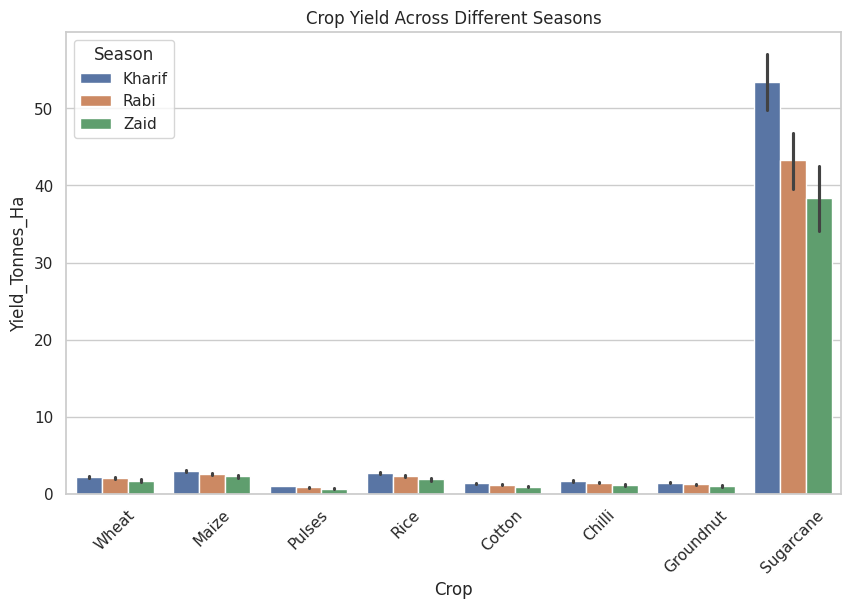

In [33]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='Crop',y='Yield_Tonnes_Ha',hue='Season')
plt.title('Crop Yield Across Different Seasons')
plt.xticks(rotation=45)
plt.show()

# 12. Correlation Analysis

Correlation analysis is used to identify the strength and direction of relationships between numerical agricultural variables.

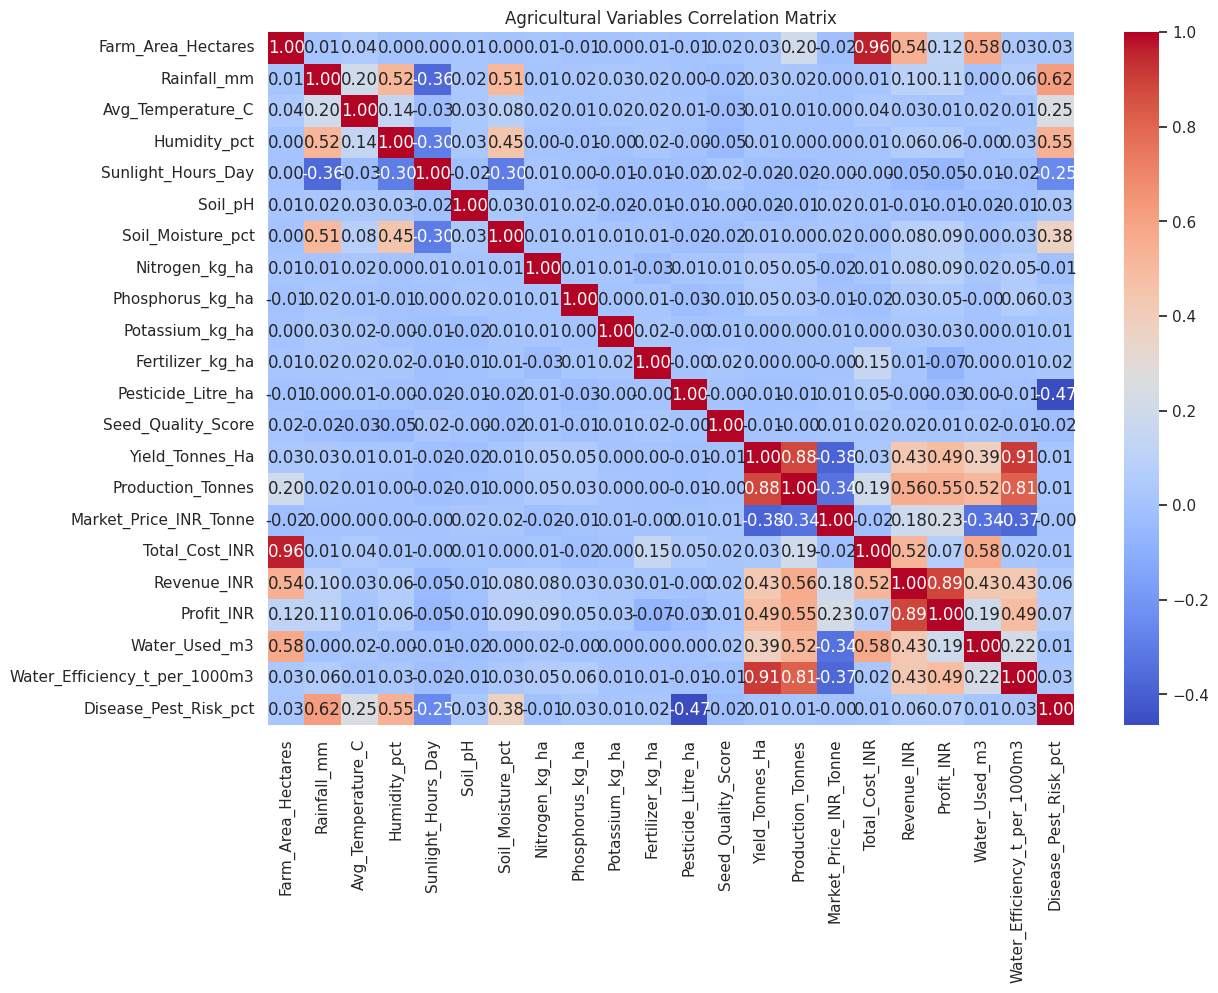

In [34]:
corr=df.select_dtypes('number').corr()

plt.figure(figsize=(13,9))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Agricultural Variables Correlation Matrix')
plt.show()

In [35]:
corr['Yield_Tonnes_Ha'].sort_values(ascending=False).round(2)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.00
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Rainfall_mm,0.03
Total_Cost_INR,0.03


# 13. Seasonal Performance Analysis

The following analysis compares major performance indicators across Kharif, Rabi and Zaid seasons.

In [36]:
season_kpi=df.groupby('Season')[
    ['Yield_Tonnes_Ha','Production_Tonnes','Revenue_INR',
     'Total_Cost_INR','Profit_INR',
     'Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']
].mean().round(2)

season_kpi

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,5.89,54.47
Rabi,5.04,41.49,601526.05,513836.58,87689.47,5.19,40.48
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,4.41,38.22


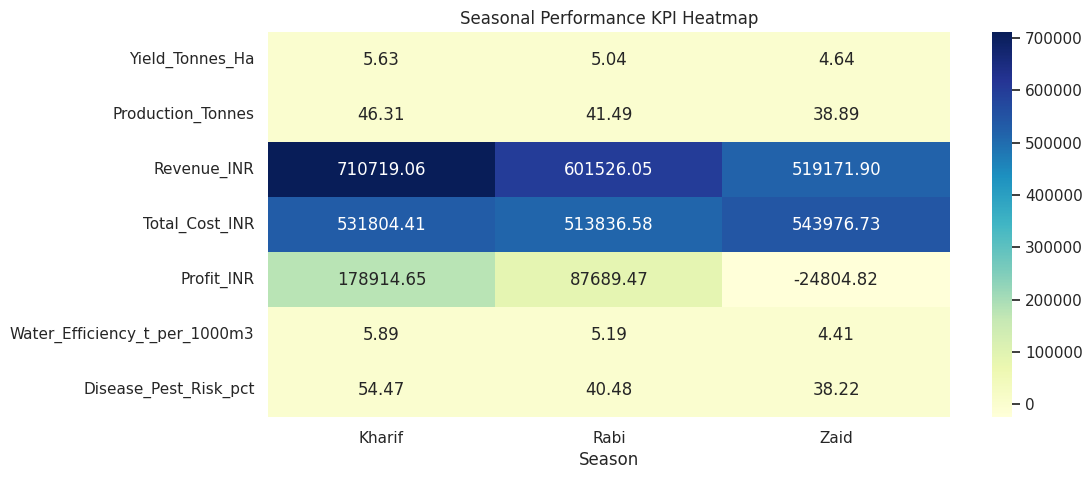

In [37]:
plt.figure(figsize=(11,5))
sns.heatmap(season_kpi.T,annot=True,fmt='.2f',cmap='YlGnBu')
plt.title('Seasonal Performance KPI Heatmap')
plt.show()

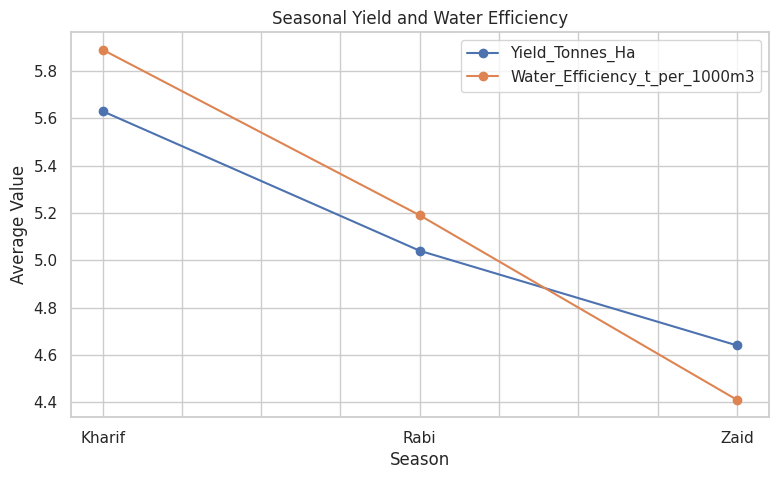

In [38]:
season_kpi[['Yield_Tonnes_Ha','Water_Efficiency_t_per_1000m3']].plot(
    marker='o',figsize=(9,5)
)
plt.title('Seasonal Yield and Water Efficiency')
plt.ylabel('Average Value')
plt.grid(True)
plt.show()

# 14. Crop Performance Analysis

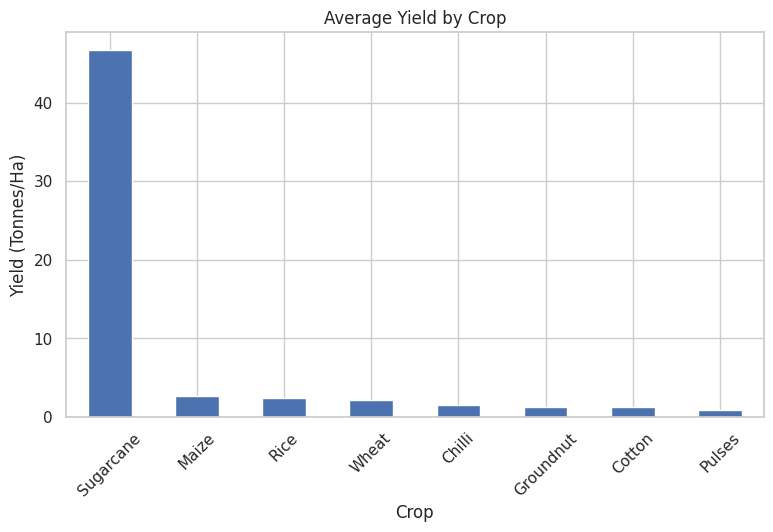

In [39]:
crop_yield=df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
crop_yield.plot(kind='bar')
plt.title('Average Yield by Crop')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

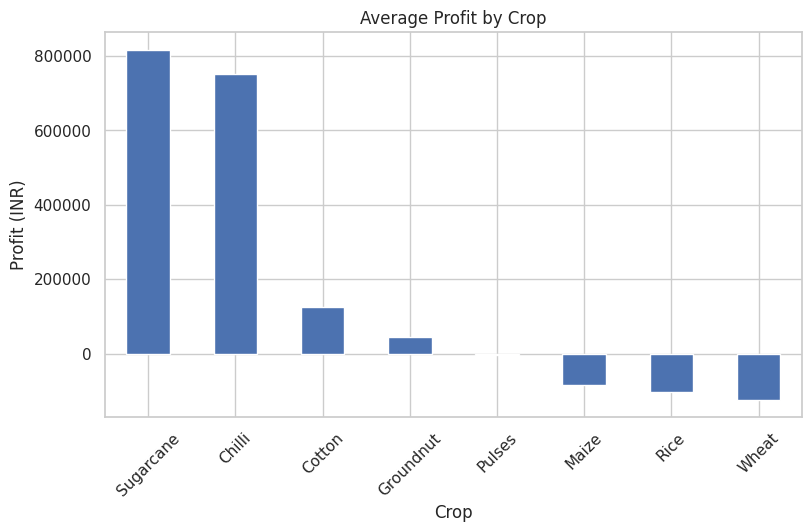

In [40]:
crop_profit=df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
crop_profit.plot(kind='bar')
plt.title('Average Profit by Crop')
plt.ylabel('Profit (INR)')
plt.xticks(rotation=45)
plt.show()

# 15. Irrigation Efficiency Analysis

In [41]:
irrigation=df.groupby('Irrigation_Method')[
    ['Yield_Tonnes_Ha','Profit_INR','Water_Efficiency_t_per_1000m3']
].mean().round(2)

irrigation

,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,
Drip,6.58,219626.00,6.27
Flood,4.86,73354.02,3.44
Rainfed,4.60,79050.37,7.56
Sprinkler,5.16,91121.08,4.67


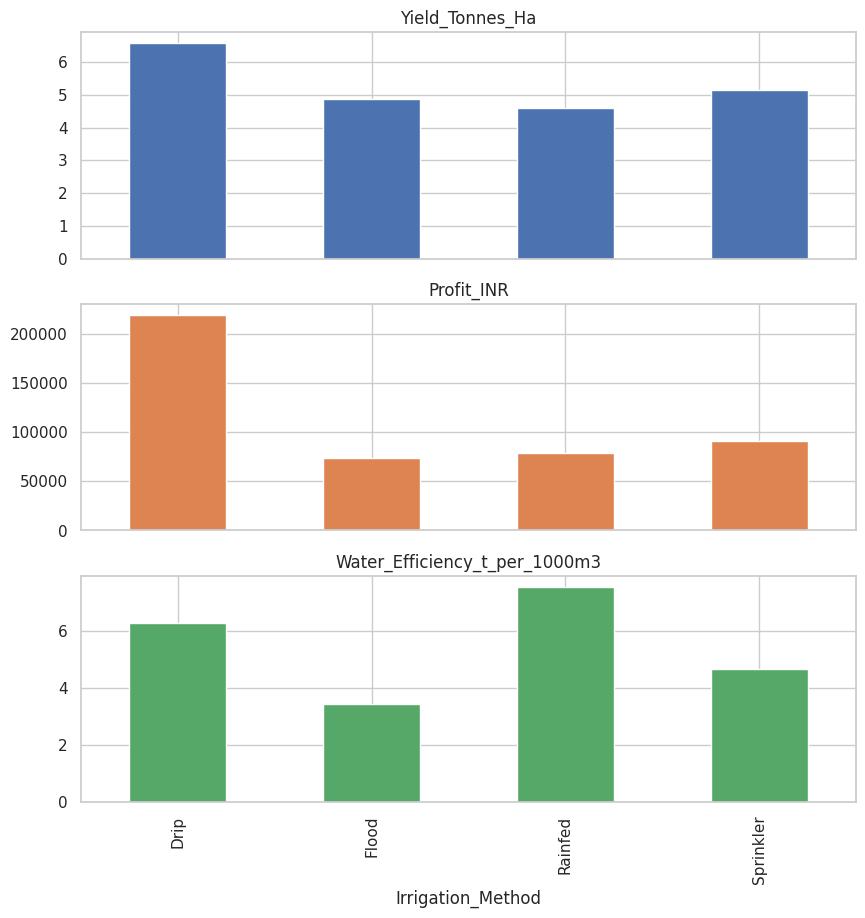

In [42]:
irrigation.plot(kind='bar',subplots=True,figsize=(10,10),legend=False)
plt.show()

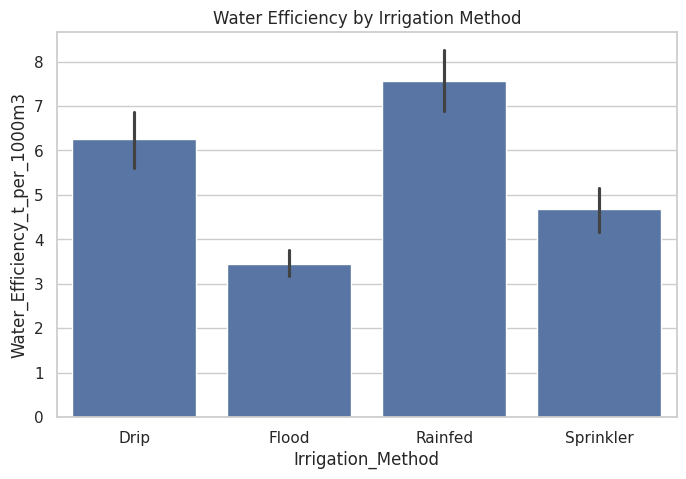

In [43]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='Irrigation_Method',y='Water_Efficiency_t_per_1000m3')
plt.title('Water Efficiency by Irrigation Method')
plt.show()

# 16. State-Level Agricultural Performance

In [44]:
state=df.groupby('State')[['Yield_Tonnes_Ha','Profit_INR']].mean().sort_values('Yield_Tonnes_Ha',ascending=False)
state

,Yield_Tonnes_Ha,Profit_INR
State,,
Punjab,6.121116,136025.636364
Karnataka,5.685481,119422.335378
Gujarat,5.659016,117568.235656
Telangana,5.044477,108829.616279
Maharashtra,5.017480,135428.855469
Madhya Pradesh,4.989940,86840.756539
Tamil Nadu,4.875175,117744.748454
Andhra Pradesh,4.628771,73453.527410


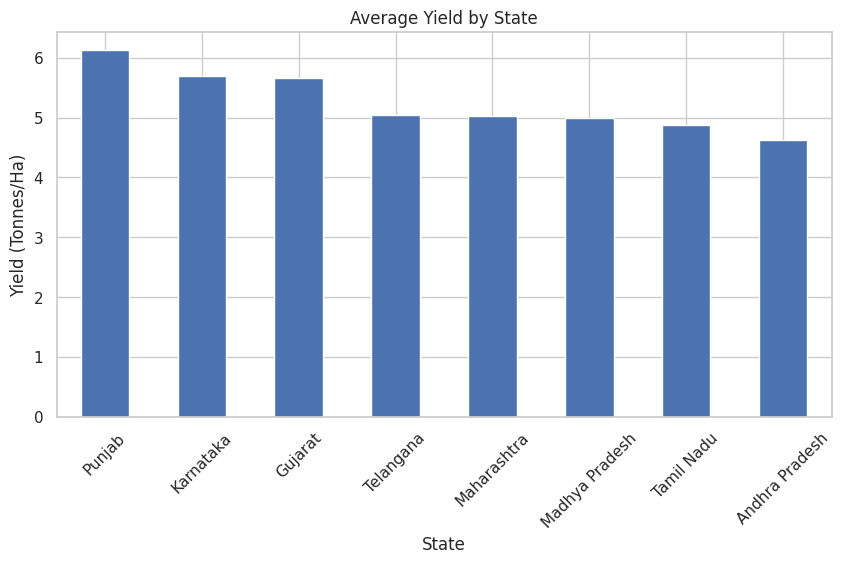

In [45]:
plt.figure(figsize=(10,5))
state['Yield_Tonnes_Ha'].plot(kind='bar')
plt.title('Average Yield by State')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

# 17. Student-Designed Analysis 1

## Which crop performs best in each season?

This analysis identifies the crop with the highest average yield within each season.

In [46]:
best=df.groupby(['Season','Crop'])['Yield_Tonnes_Ha'].mean().reset_index()
best.loc[best.groupby('Season')['Yield_Tonnes_Ha'].idxmax()]

,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.459120
14,Rabi,Sugarcane,43.286124
22,Zaid,Sugarcane,38.423922


# 18. Student-Designed Analysis 2

## Which crops combine profitability with efficient water usage?

This analysis compares average crop profit and water efficiency to identify potentially efficient crop choices.

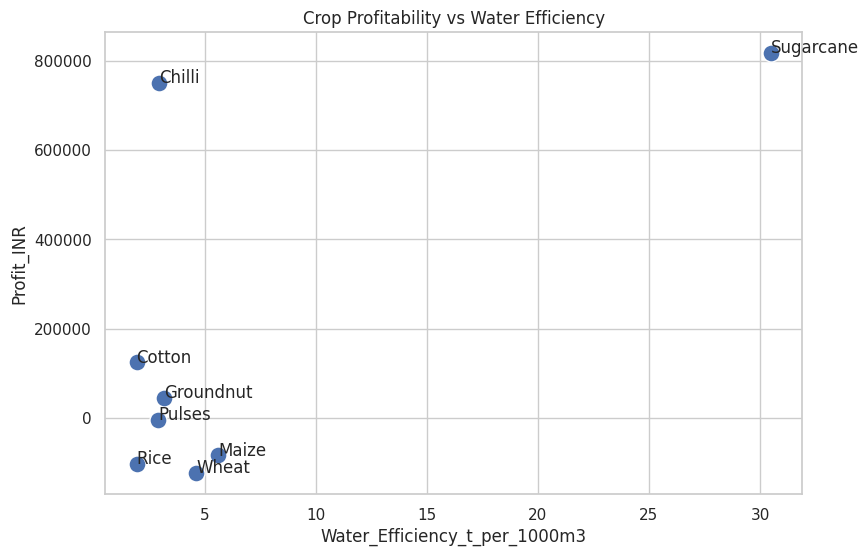

In [47]:
crop_eff=df.groupby('Crop')[
    ['Profit_INR','Water_Efficiency_t_per_1000m3']
].mean()

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=crop_eff,
    x='Water_Efficiency_t_per_1000m3',
    y='Profit_INR',
    s=150
)

for i,r in crop_eff.iterrows():
    plt.text(r['Water_Efficiency_t_per_1000m3'],r['Profit_INR'],i)

plt.title('Crop Profitability vs Water Efficiency')
plt.show()

crop_eff=df.groupby('Crop')[
    ['Profit_INR','Water_Efficiency_t_per_1000m3']
].mean()

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=crop_eff,
    x='Water_Efficiency_t_per_1000m3',
    y='Profit_INR',
    s=150
)

for i,r in crop_eff.iterrows():
    plt.text(r['Water_Efficiency_t_per_1000m3'],r['Profit_INR'],i)

plt.title('Crop Profitability vs Water Efficiency')
plt.show()

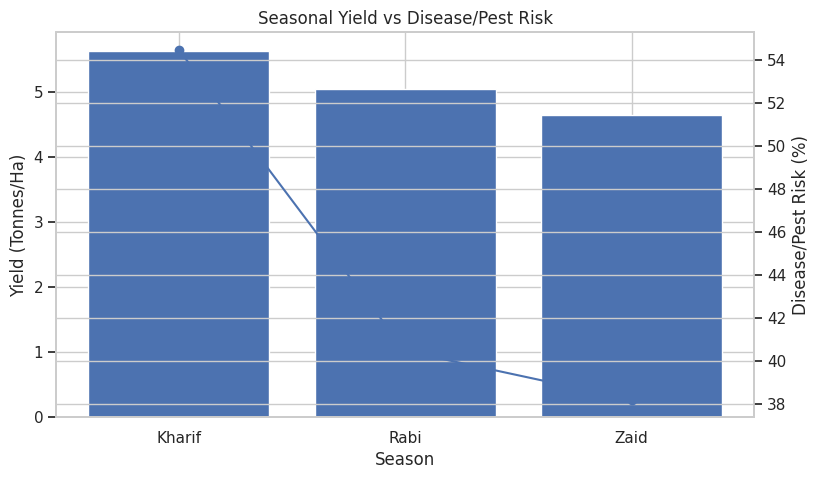

In [48]:
risk=df.groupby('Season')[['Yield_Tonnes_Ha','Disease_Pest_Risk_pct']].mean()

fig,ax1=plt.subplots(figsize=(9,5))

ax1.bar(risk.index,risk['Yield_Tonnes_Ha'])
ax1.set_ylabel('Yield (Tonnes/Ha)')
ax1.set_xlabel('Season')

ax2=ax1.twinx()
ax2.plot(risk.index,risk['Disease_Pest_Risk_pct'],marker='o')
ax2.set_ylabel('Disease/Pest Risk (%)')

plt.title('Seasonal Yield vs Disease/Pest Risk')
plt.show()

# 20. Crop-Season Performance Heatmap

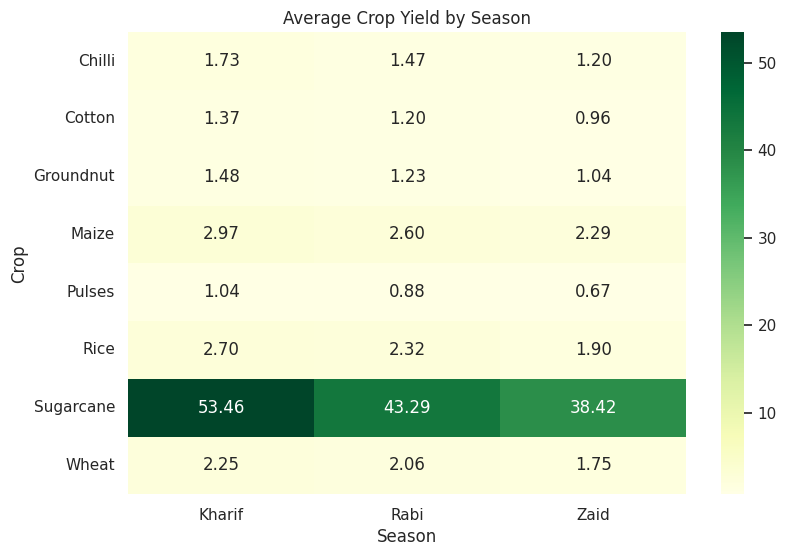

In [49]:
x=df.pivot_table(
    index='Crop',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
)

plt.figure(figsize=(9,6))
sns.heatmap(x,annot=True,fmt='.2f',cmap='YlGn')
plt.title('Average Crop Yield by Season')
plt.show()

# 21. Profitability vs Yield

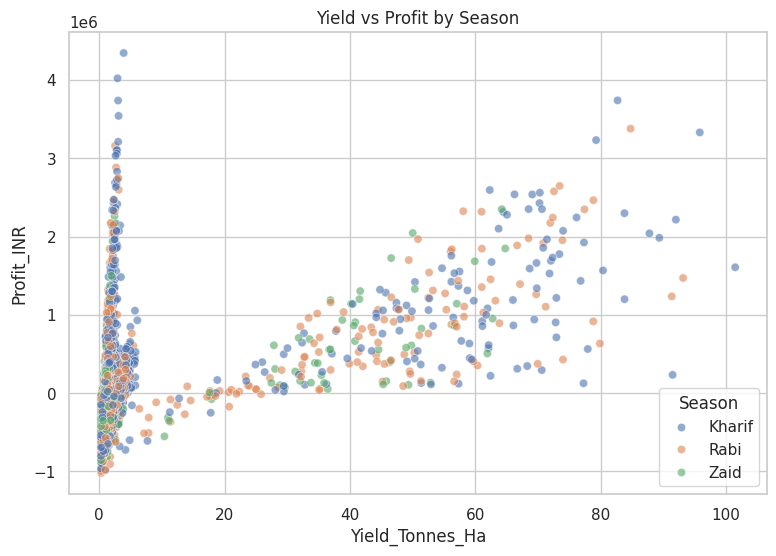

In [50]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x='Yield_Tonnes_Ha',
    y='Profit_INR',
    hue='Season',
    alpha=.6
)
plt.title('Yield vs Profit by Season')
plt.show()

# 22. Production Efficiency

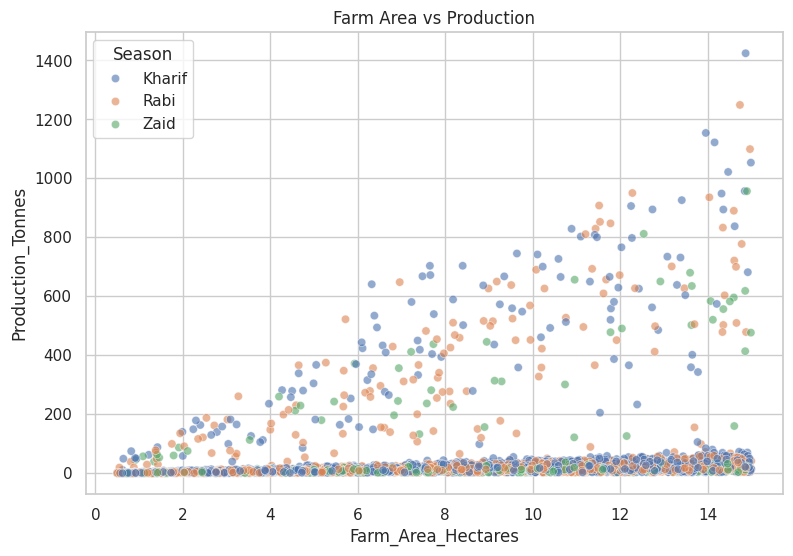

In [51]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x='Farm_Area_Hectares',
    y='Production_Tonnes',
    hue='Season',
    alpha=.6
)
plt.title('Farm Area vs Production')
plt.show()

# 23. Market Price vs Profit

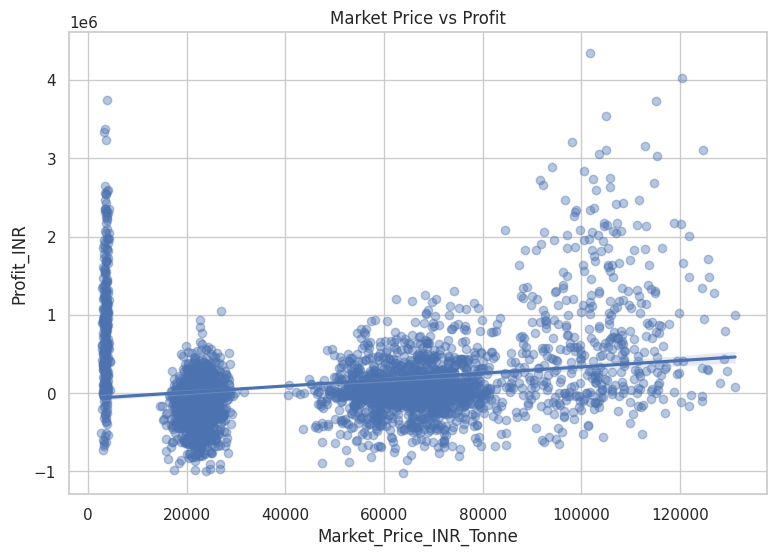

In [52]:
plt.figure(figsize=(9,6))
sns.regplot(
    data=df,
    x='Market_Price_INR_Tonne',
    y='Profit_INR',
    scatter_kws={'alpha':.4}
)
plt.title('Market Price vs Profit')
plt.show()

# 24. Key Insights

### Insight 1 – Seasonal Yield
Kharif shows the highest average yield in the dataset at approximately 5.63 tonnes/ha, followed by Rabi and Zaid.

### Insight 2 – Seasonal Distribution
Kharif contains the largest number of records, followed by Rabi and Zaid.

### Insight 3 – Crop Performance
Sugarcane has the highest average yield among the crops in this dataset.

### Insight 4 – Crop Profitability
Sugarcane records the highest average profit, followed by Chilli.

### Insight 5 – Irrigation Performance
Drip irrigation shows the highest average yield and average profit among the irrigation methods in the dataset.

### Insight 6 – Water Efficiency
Rainfed farming shows the highest average water-efficiency value, while Drip irrigation provides a stronger combination of yield and profit.

### Insight 7 – State Performance
Punjab has the highest average yield among the states represented in the dataset.

### Insight 8 – Yield Relationships
Yield has strong positive relationships with production and water efficiency, while profitability and revenue also show positive relationships with yield.

### Insight 9 – Seasonal Risk
Kharif has the highest average disease/pest risk among the three seasons in the dataset.

### Insight 10 – Variation
Box plots reveal considerable variation and outliers in production, yield, profit and water-use-related variables.

# 25. Evidence-Based Recommendations

1. **Focus on seasonal planning:** Kharif shows the strongest average yield in the analyzed dataset, so seasonal planning should consider its favorable performance conditions.

2. **Promote efficient irrigation:** Drip irrigation shows strong yield and profitability performance and should be considered where economically and geographically feasible.

3. **Improve water management:** Water-efficiency measures should be incorporated into farm planning to improve productivity from available water resources.

4. **Crop selection should consider profitability:** Crop selection should consider both yield and market profitability rather than yield alone.

5. **Monitor disease and pest risk:** Higher-risk seasons should receive stronger pest monitoring and preventive management.

6. **Use data-driven input planning:** Fertilizer, pesticide and other agricultural inputs should be optimized based on observed yield and profitability relationships.

7. **Consider local conditions:** State, crop and seasonal differences indicate that a single agricultural strategy may not be equally effective everywhere.

# 26. Limitations

- The analysis is based only on the provided dataset.
- The dataset represents a specific set of farms, locations and seasons.
- Correlation does not prove causation.
- Missing numerical values were handled using median imputation.
- Extreme values may represent genuine agricultural conditions and were therefore not automatically removed.
- Market prices, weather conditions and farming practices can vary over time.
- Results should not automatically be generalized to all agricultural regions.

# 27. Conclusion

The Seasonal Agriculture Performance Analysis examined 4,000 agricultural records across different crops, states, districts, seasons and irrigation methods.

The analysis combined data cleaning, descriptive statistics, univariate, bivariate and multivariate analysis, outlier detection, correlation analysis and seasonal comparisons.

The results show meaningful differences in yield, production, profitability, water efficiency and disease/pest risk across seasons and farming conditions. Kharif records the highest average yield in the dataset, while crop and irrigation-level analysis reveals important differences in agricultural performance.

Overall, the project demonstrates how data analytics and visualization can transform raw agricultural data into useful insights for seasonal planning, crop selection, resource management and evidence-based agricultural decision-making.

# Project Completion Checklist

Before submission, confirm that your notebook includes:

- [ ] Dataset loaded successfully
- [ ] Top 5 rows analyzed
- [ ] Dataset shape and structure examined
- [ ] Data types examined
- [ ] Missing values identified and handled
- [ ] Duplicate records identified and handled
- [ ] Descriptive/statistical analysis performed
- [ ] Outliers investigated
- [ ] Univariate analysis completed
- [ ] Bivariate analysis completed
- [ ] Multivariate analysis completed
- [ ] Correlation analysis completed
- [ ] Seasonal comparisons performed
- [ ] At least 3 student-designed analyses completed
- [ ] At least 8 meaningful insights documented
- [ ] Evidence-based recommendations provided
- [ ] Limitations discussed
- [ ] Final conclusion provided